# Project 9
## Forecasting Smart City Traffic Patterns

### Objective
Develop machine learning models to forecast traffic volume at different city junctions to assist the government in traffic management and future infrastructure planning.

In [1]:
!pip install xgboost catboost lightgbm holidays joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.6 MB/s eta 0:00:00


In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import joblib

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE_DIR = "/content/drive/MyDrive/Project09"

folders = [
    "Dataset",
    "Models",
    "Plots",
    "Results",
    "EDA",
    "Predictions"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("Folder Structure Created Successfully")

Folder Structure Created Successfully


In [7]:
# ======================================
# Copy Dataset to Local SSD
# ======================================

LOCAL_DIR = "/content/Project_9"

os.makedirs(LOCAL_DIR, exist_ok=True)

TRAIN_SOURCE = os.path.join(BASE_DIR, "Dataset", "train.csv")
TEST_SOURCE  = os.path.join(BASE_DIR, "Dataset", "test.csv")

TRAIN_LOCAL = os.path.join(LOCAL_DIR, "train.csv")
TEST_LOCAL  = os.path.join(LOCAL_DIR, "test.csv")

shutil.copy(TRAIN_SOURCE, TRAIN_LOCAL)
shutil.copy(TEST_SOURCE, TEST_LOCAL)

print("Datasets copied successfully!")

print("\nLocal Files:")
print(os.listdir(LOCAL_DIR))

Datasets copied successfully!

Local Files:
['train.csv', 'test.csv']


In [8]:
# ======================================
# Load Dataset from Local SSD
# ======================================

train = pd.read_csv(TRAIN_LOCAL)
test = pd.read_csv(TEST_LOCAL)

print("Train Dataset Shape :", train.shape)
print("Test Dataset Shape  :", test.shape)

Train Dataset Shape : (48120, 4)
Test Dataset Shape  : (11808, 3)


In [9]:
# ======================================
# Display Dataset Samples
# ======================================

print("Training Dataset")
display(train.head())

print("\nTesting Dataset")
display(test.head())

print("\nRandom Samples from Training Dataset")
display(train.sample(5, random_state=42))

Training Dataset


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041



Testing Dataset


,DateTime,Junction,ID
0,2017-07-01 00:00:00,1,20170701001
1,2017-07-01 01:00:00,1,20170701011
2,2017-07-01 02:00:00,1,20170701021
3,2017-07-01 03:00:00,1,20170701031
4,2017-07-01 04:00:00,1,20170701041



Random Samples from Training Dataset


,DateTime,Junction,Vehicles,ID
24632,2016-12-23 08:00:00,2,9,20161223082
36428,2016-08-28 20:00:00,3,97,20160828203
42150,2017-04-24 06:00:00,3,13,20170424063
23885,2016-11-22 05:00:00,2,11,20161122052
2174,2016-01-30 14:00:00,1,24,20160130141


In [10]:
# ======================================
# Dataset Information
# ======================================

print("="*60)
print("TRAIN DATASET INFORMATION")
print("="*60)

train.info()

print("\n")

print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)

display(train.describe(include="all"))

TRAIN DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


STATISTICAL SUMMARY


,DateTime,Junction,Vehicles,ID
count,48120,48120.000000,48120.000000,4.812000e+04
unique,14592,NaN,NaN,NaN
top,2017-06-30 08:00:00,NaN,NaN,NaN
freq,4,NaN,NaN,NaN
mean,NaN,2.180549,22.791334,2.016330e+10
std,NaN,0.966955,20.750063,5.944854e+06
min,NaN,1.000000,1.000000,2.015110e+10
25%,NaN,1.000000,9.000000,2.016042e+10
50%,NaN,2.000000,15.000000,2.016093e+10
75%,NaN,3.000000,29.000000,2.017023e+10


In [11]:
# ======================================
# Missing Value Analysis
# ======================================

missing_values = train.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Percentage (%)": (missing_values.values / len(train)) * 100
})

display(missing_df)

if missing_values.sum() == 0:
    print("\n✅ No Missing Values Found.")
else:
    print("\n⚠ Missing Values Detected.")

,Column,Missing Values,Percentage (%)
0,DateTime,0,0.0
1,Junction,0,0.0
2,Vehicles,0,0.0
3,ID,0,0.0



✅ No Missing Values Found.


In [12]:
# ======================================
# Duplicate Value Analysis
# ======================================

duplicate_rows = train.duplicated().sum()

print(f"Duplicate Rows Found : {duplicate_rows}")

if duplicate_rows > 0:
    train.drop_duplicates(inplace=True)
    train.reset_index(drop=True, inplace=True)
    print("Duplicate rows removed successfully.")
else:
    print("No duplicate rows found.")

print("\nUpdated Dataset Shape:", train.shape)

Duplicate Rows Found : 0
No duplicate rows found.

Updated Dataset Shape: (48120, 4)


In [13]:
# ======================================
# Convert DateTime Column
# ======================================

train["DateTime"] = pd.to_datetime(train["DateTime"])
test["DateTime"] = pd.to_datetime(test["DateTime"])

print("Train DateTime dtype :", train["DateTime"].dtype)
print("Test DateTime dtype  :", test["DateTime"].dtype)

display(train.head())

Train DateTime dtype : datetime64[ns]
Test DateTime dtype  : datetime64[ns]


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [14]:
# ======================================
# Feature Engineering - Date & Time
# ======================================

for df in [train, test]:

    df["Year"] = df["DateTime"].dt.year
    df["Month"] = df["DateTime"].dt.month
    df["Day"] = df["DateTime"].dt.day

    df["Hour"] = df["DateTime"].dt.hour
    df["Minute"] = df["DateTime"].dt.minute

    df["DayOfWeek"] = df["DateTime"].dt.dayofweek
    df["DayName"] = df["DateTime"].dt.day_name()

    df["WeekOfYear"] = df["DateTime"].dt.isocalendar().week.astype(int)
    df["Quarter"] = df["DateTime"].dt.quarter

print("Date & Time Features Created Successfully!")

display(train.head())

Date & Time Features Created Successfully!


,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,Minute,DayOfWeek,DayName,WeekOfYear,Quarter
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,0,6,Sunday,44,4
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,0,6,Sunday,44,4
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,0,6,Sunday,44,4
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,0,6,Sunday,44,4
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,0,6,Sunday,44,4


In [15]:
# ======================================
# Create Traffic Related Features
# ======================================

for df in [train, test]:

    # Weekend Indicator
    df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

    # Office Rush Hours
    df["PeakHour"] = df["Hour"].apply(
        lambda x: 1 if (7 <= x <= 10) or (16 <= x <= 20) else 0
    )

print("Weekend & Peak Hour Features Added!")

display(train.head())

Weekend & Peak Hour Features Added!


,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,Minute,DayOfWeek,DayName,WeekOfYear,Quarter,IsWeekend,PeakHour
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,0,6,Sunday,44,4,1,0
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,0,6,Sunday,44,4,1,0
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,0,6,Sunday,44,4,1,0
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,0,6,Sunday,44,4,1,0
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,0,6,Sunday,44,4,1,0


In [16]:
# ======================================
# Verify New Features
# ======================================

print("Training Dataset Shape :", train.shape)
print("Testing Dataset Shape  :", test.shape)

print("\nColumns Available:\n")

display(train.columns)

print("\nPreview After Feature Engineering")

display(train.head())

Training Dataset Shape : (48120, 15)
Testing Dataset Shape  : (11808, 14)

Columns Available:



Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'Year', 'Month', 'Day',
       'Hour', 'Minute', 'DayOfWeek', 'DayName', 'WeekOfYear', 'Quarter',
       'IsWeekend', 'PeakHour'],
      dtype='object')


Preview After Feature Engineering


,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,Minute,DayOfWeek,DayName,WeekOfYear,Quarter,IsWeekend,PeakHour
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,0,6,Sunday,44,4,1,0
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,0,6,Sunday,44,4,1,0
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,0,6,Sunday,44,4,1,0
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,0,6,Sunday,44,4,1,0
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,0,6,Sunday,44,4,1,0


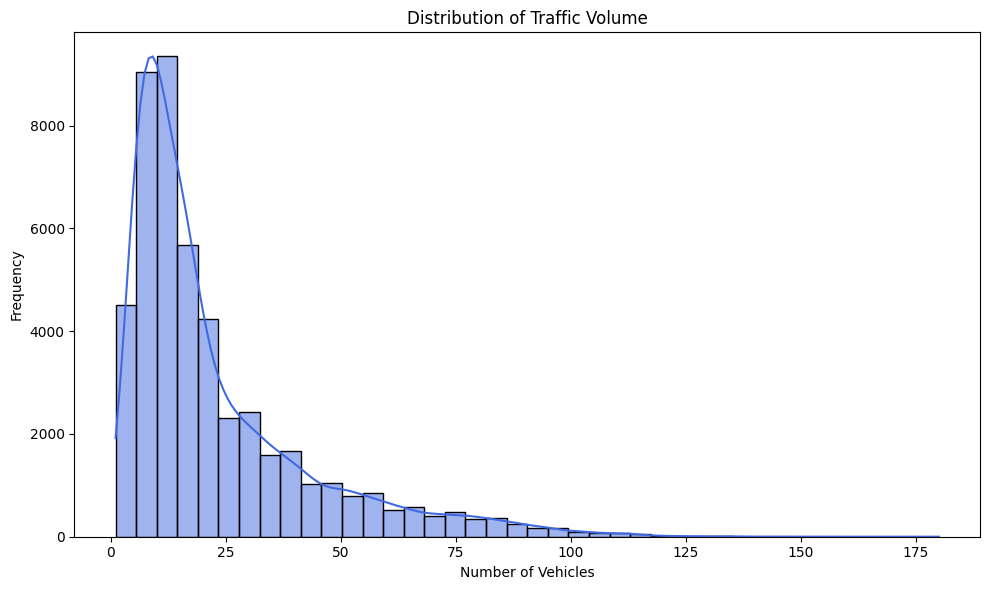

In [17]:
# ======================================
# Distribution of Traffic Volume
# ======================================

plt.figure(figsize=(10,6))

sns.histplot(
    train["Vehicles"],
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Traffic Volume")
plt.xlabel("Number of Vehicles")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    os.path.join(BASE_DIR, "EDA", "Vehicle_Distribution.png"),
    dpi=300
)

plt.show()

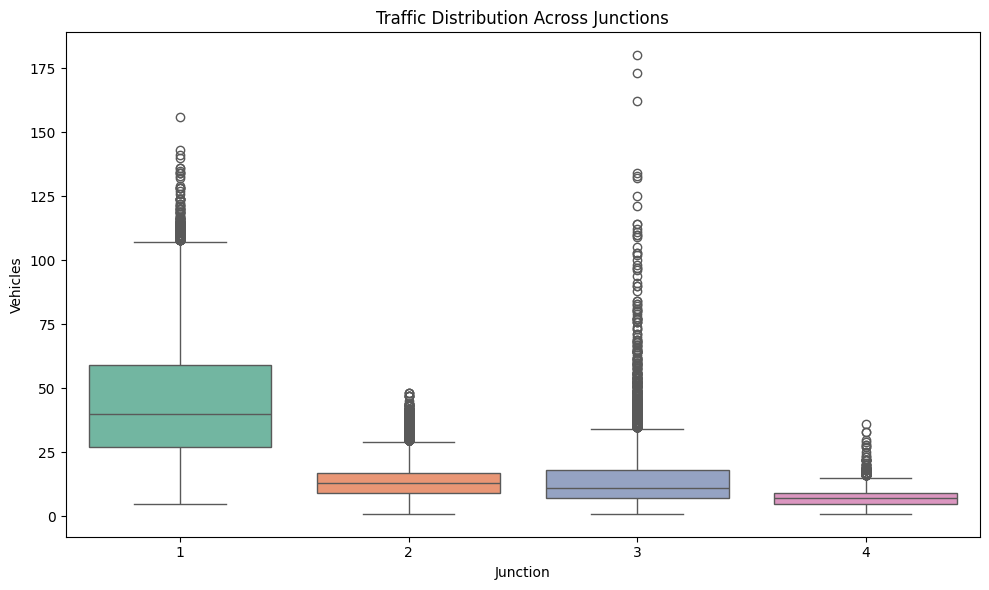

In [18]:
# ======================================
# Traffic at Different Junctions
# ======================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=train,
    x="Junction",
    y="Vehicles",
    palette="Set2"
)

plt.title("Traffic Distribution Across Junctions")
plt.xlabel("Junction")
plt.ylabel("Vehicles")

plt.tight_layout()

plt.savefig(
    os.path.join(BASE_DIR, "EDA", "Junction_Traffic.png"),
    dpi=300
)

plt.show()

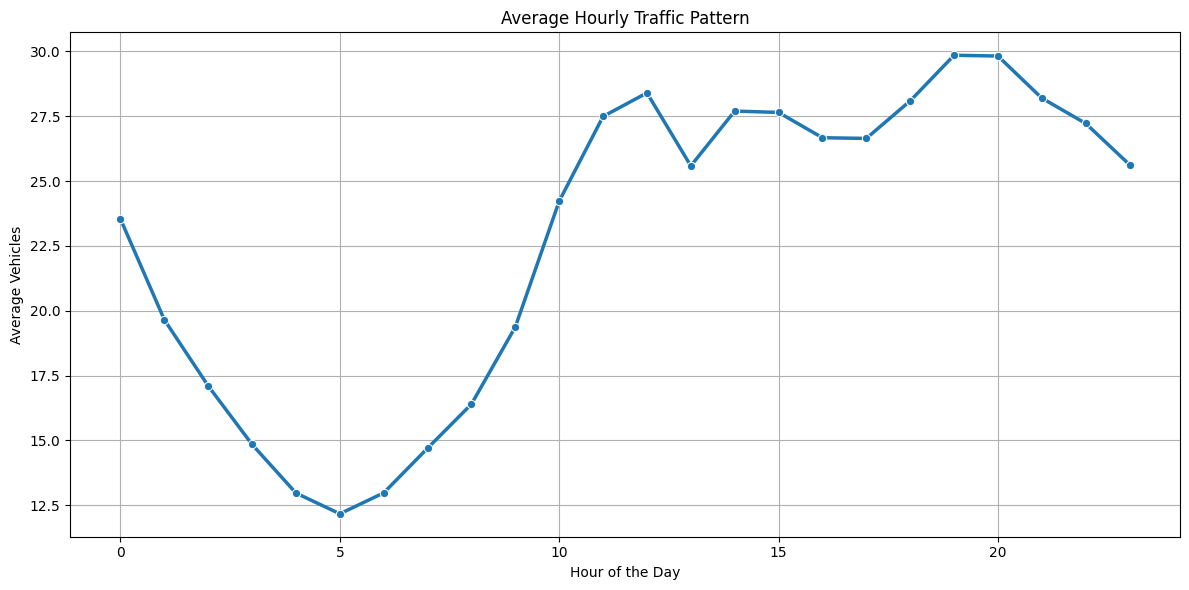

In [19]:
# ======================================
# Average Traffic by Hour
# ======================================

hourly = (
    train
    .groupby("Hour")["Vehicles"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly,
    x="Hour",
    y="Vehicles",
    marker="o",
    linewidth=2.5
)

plt.title("Average Hourly Traffic Pattern")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Vehicles")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(BASE_DIR, "EDA", "Hourly_Traffic.png"),
    dpi=300
)

plt.show()

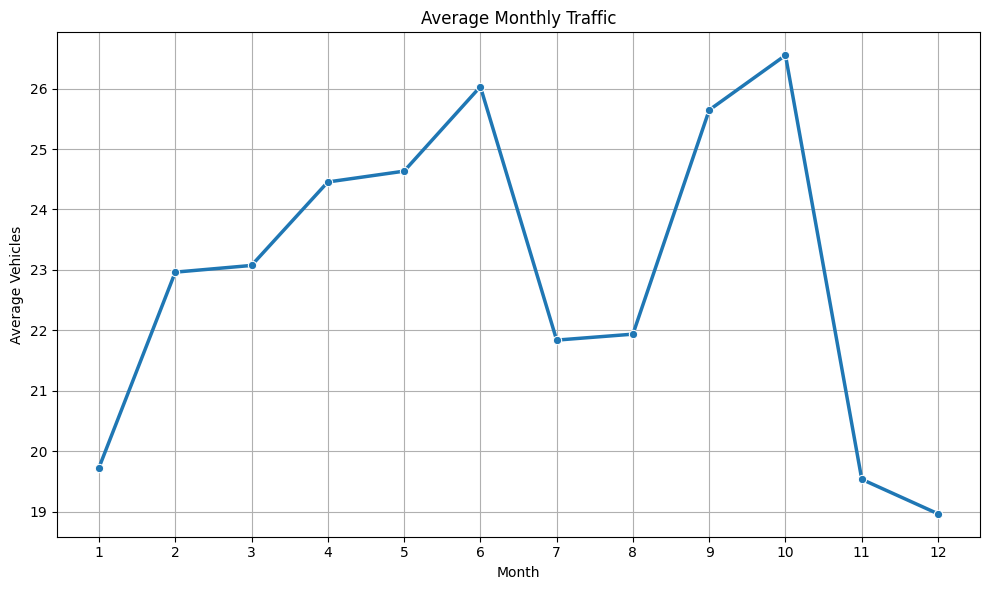

In [20]:
# ======================================
# Monthly Average Traffic
# ======================================

monthly = (
    train.groupby("Month")["Vehicles"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly,
    x="Month",
    y="Vehicles",
    marker="o",
    linewidth=2.5
)

plt.title("Average Monthly Traffic")
plt.xlabel("Month")
plt.ylabel("Average Vehicles")

plt.xticks(range(1,13))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(BASE_DIR, "EDA", "Monthly_Traffic.png"),
    dpi=300
)

plt.show()

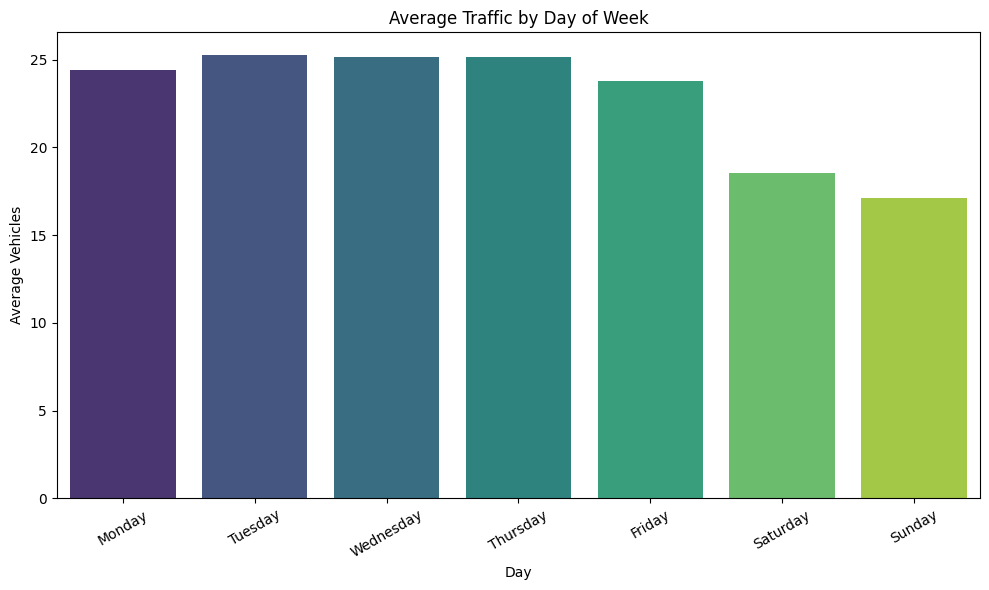

In [21]:
# ======================================
# Average Traffic by Day of Week
# ======================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daywise = (
    train.groupby("DayName")["Vehicles"]
    .mean()
    .reindex(day_order)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=daywise,
    x="DayName",
    y="Vehicles",
    palette="viridis"
)

plt.title("Average Traffic by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Vehicles")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    os.path.join(BASE_DIR, "EDA", "Daywise_Traffic.png"),
    dpi=300
)

plt.show()

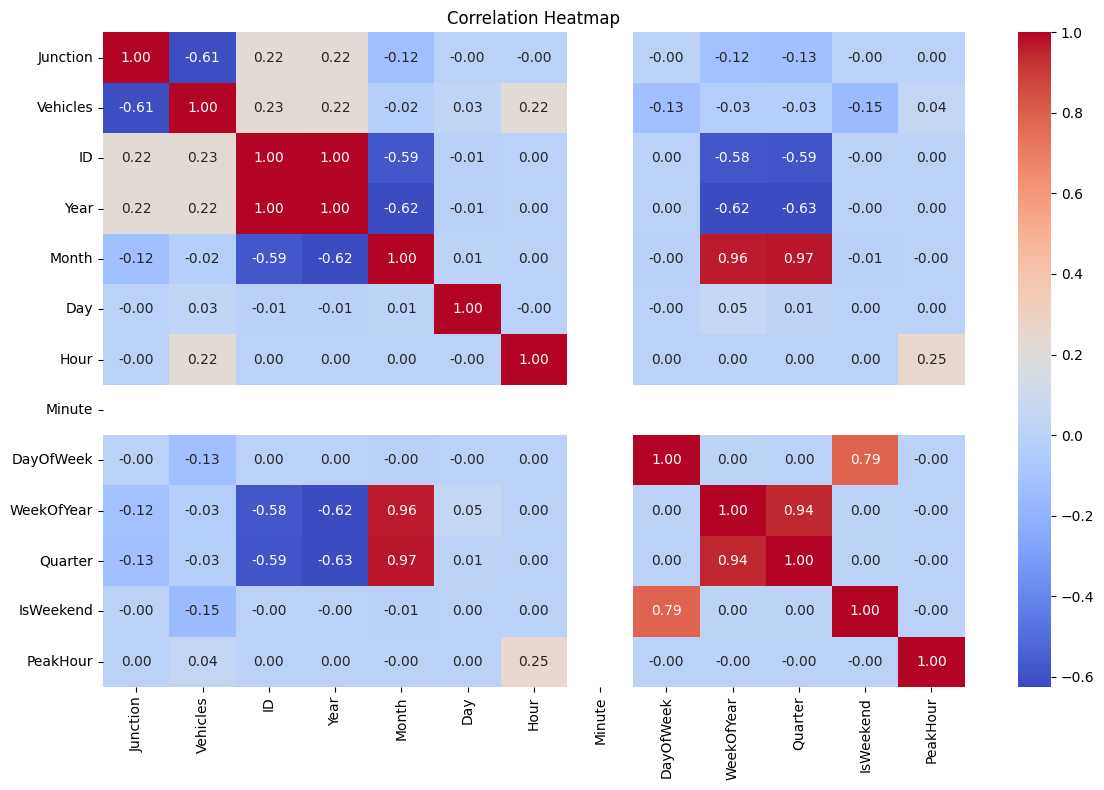

In [22]:
# ======================================
# Correlation Heatmap
# ======================================

numeric_df = train.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    os.path.join(BASE_DIR, "EDA", "Correlation_Heatmap.png"),
    dpi=300
)

plt.show()

In [23]:
# ======================================
# Encode Categorical Features
# ======================================

train["DayName"] = train["DayName"].astype("category").cat.codes
test["DayName"] = test["DayName"].astype("category").cat.codes

print("Categorical Encoding Completed!")

display(train.head())

Categorical Encoding Completed!


,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,Minute,DayOfWeek,DayName,WeekOfYear,Quarter,IsWeekend,PeakHour
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,0,6,3,44,4,1,0
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,0,6,3,44,4,1,0
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,0,6,3,44,4,1,0
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,0,6,3,44,4,1,0
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,0,6,3,44,4,1,0


In [24]:
# ======================================
# Prepare Features & Target
# ======================================

FEATURES = [
    "Junction",
    "Year",
    "Month",
    "Day",
    "Hour",
    "Minute",
    "DayOfWeek",
    "DayName",
    "WeekOfYear",
    "Quarter",
    "IsWeekend",
    "PeakHour"
]

TARGET = "Vehicles"

X = train[FEATURES]
y = train[TARGET]

X_submission = test[FEATURES]

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Matrix Shape : (48120, 12)
Target Shape         : (48120,)


In [25]:
# ======================================
# Time-Based Train Validation Split
# ======================================

# Ensure chronological order
train = train.sort_values("DateTime").reset_index(drop=True)

X = train[FEATURES]
y = train[TARGET]

split_index = int(len(train) * 0.80)

X_train = X.iloc[:split_index]
X_valid = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_valid = y.iloc[split_index:]

print("="*50)
print("Training Samples   :", len(X_train))
print("Validation Samples :", len(X_valid))
print("="*50)

Training Samples   : 38496
Validation Samples : 9624


In [26]:
# ======================================
# Linear Regression
# ======================================

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_valid)

print("Linear Regression Training Completed!")

Linear Regression Training Completed!


In [27]:
# ======================================
# Random Forest Regressor
# ======================================

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)

print("Random Forest Training Completed!")

Random Forest Training Completed!


In [28]:
# ======================================
# XGBoost Regressor
# ======================================

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_valid)

print("XGBoost Training Completed!")

XGBoost Training Completed!


In [29]:
# ======================================
# CatBoost Regressor
# ======================================

cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_valid)

print("CatBoost Training Completed!")

CatBoost Training Completed!


In [30]:
# ======================================
# Evaluation Function
# ======================================

def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2 Score": round(r2, 4)
    }

print("Evaluation Function Ready!")

Evaluation Function Ready!


In [31]:
# ======================================
# Model Comparison
# ======================================

results = pd.DataFrame([

    evaluate_model("Linear Regression", y_valid, lr_pred),

    evaluate_model("Random Forest", y_valid, rf_pred),

    evaluate_model("XGBoost", y_valid, xgb_pred),

    evaluate_model("CatBoost", y_valid, cat_pred)

])

results = results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

display(results)

results.to_csv(
    os.path.join(BASE_DIR, "Results", "Model_Comparison.csv"),
    index=False
)

print("Model comparison saved successfully!")

,Model,MAE,RMSE,R2 Score
0,XGBoost,5.013,7.880,0.9162
1,Random Forest,4.939,8.423,0.9043
2,CatBoost,7.555,11.920,0.8083
3,Linear Regression,11.503,16.584,0.6290


Model comparison saved successfully!


,Feature,Importance
0,Junction,0.522255
4,Hour,0.144845
1,Year,0.127907
2,Month,0.047300
6,DayOfWeek,0.039120
8,WeekOfYear,0.035843
10,IsWeekend,0.028662
3,Day,0.025745
9,Quarter,0.017073
7,DayName,0.008744


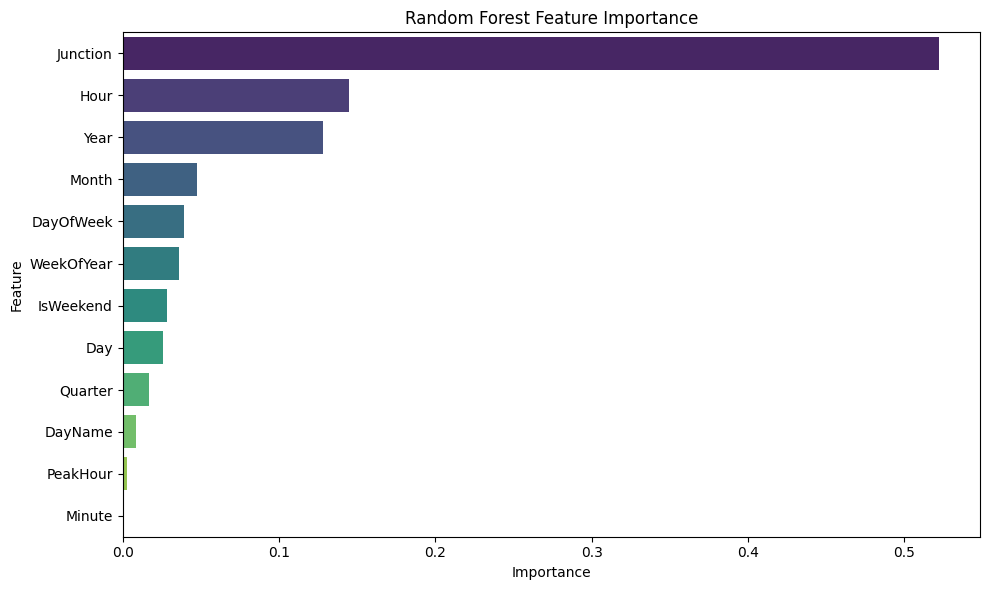

In [32]:
# ======================================
# Feature Importance
# ======================================

importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    os.path.join(BASE_DIR, "Plots", "Feature_Importance.png"),
    dpi=300
)

plt.show()

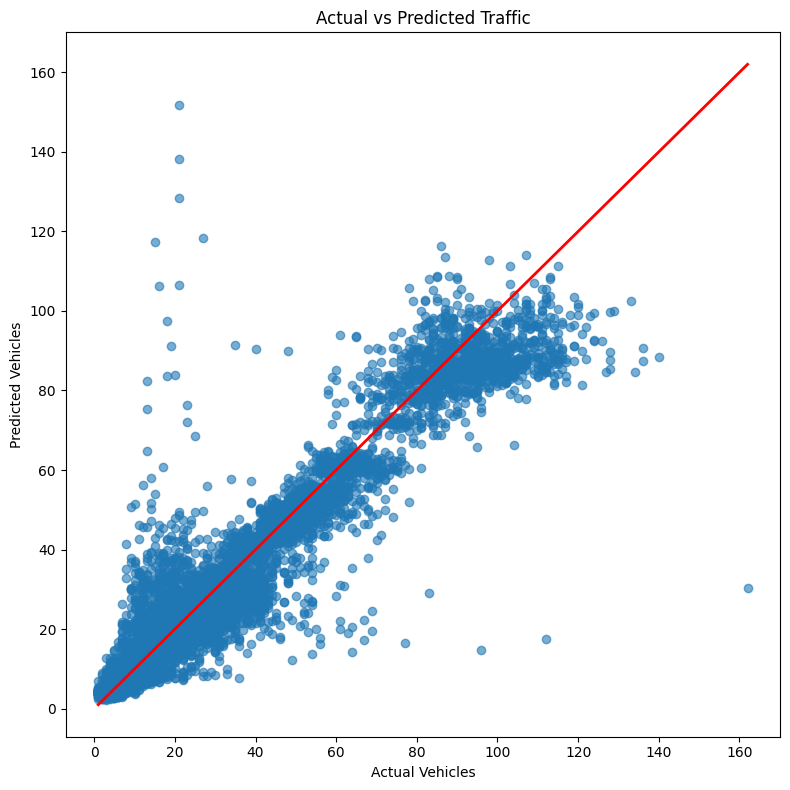

In [33]:
# ======================================
# Actual vs Predicted
# ======================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_valid,
    rf_pred,
    alpha=0.6
)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Vehicles")
plt.ylabel("Predicted Vehicles")

plt.title("Actual vs Predicted Traffic")

plt.tight_layout()

plt.savefig(
    os.path.join(BASE_DIR, "Plots", "Actual_vs_Predicted.png"),
    dpi=300
)

plt.show()

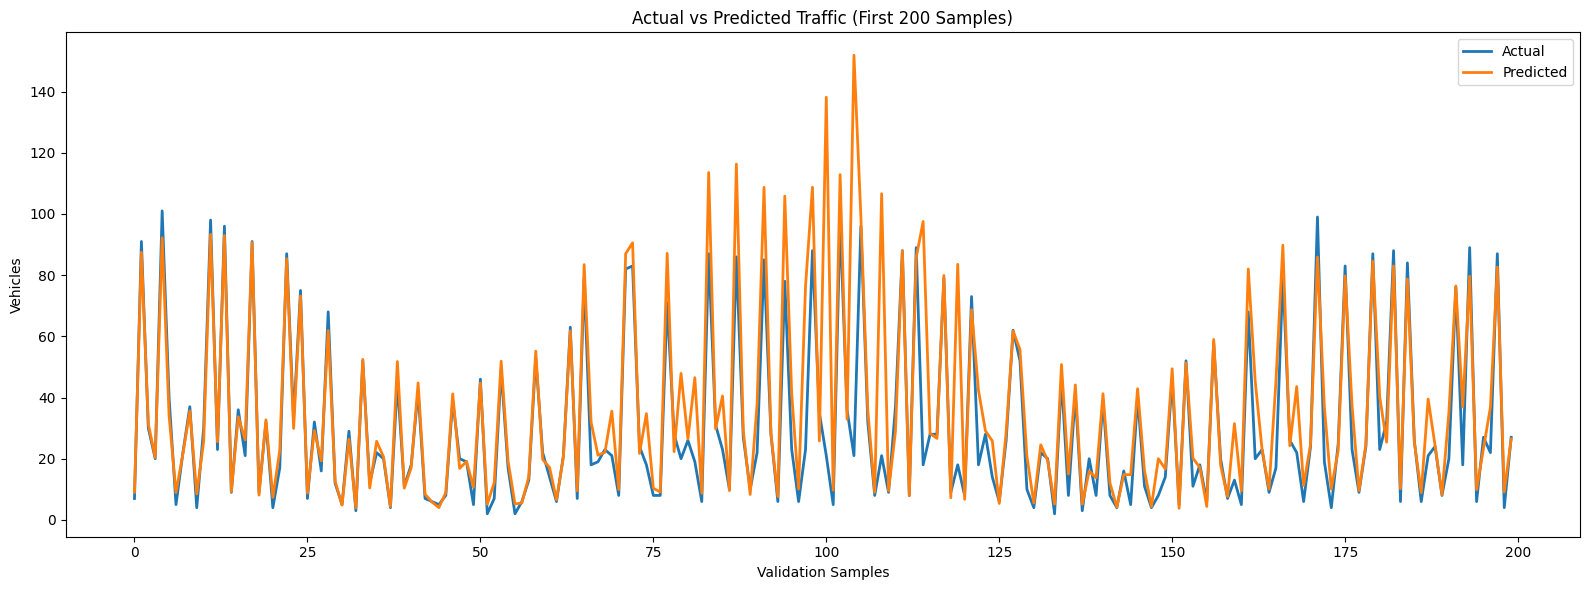

,Actual,Predicted
0,7,9.060000
1,91,87.466667
2,30,31.370111
3,20,20.398603
4,101,92.190000
5,40,34.057222
6,5,8.926667
7,22,21.602333
8,37,35.633889
9,4,8.506667


In [34]:
# ======================================
# Actual vs Predicted Trend
# ======================================

comparison = pd.DataFrame({
    "Actual": y_valid.values,
    "Predicted": rf_pred
})

comparison = comparison.reset_index(drop=True)

plt.figure(figsize=(16,6))

plt.plot(
    comparison["Actual"][:200],
    label="Actual",
    linewidth=2
)

plt.plot(
    comparison["Predicted"][:200],
    label="Predicted",
    linewidth=2
)

plt.xlabel("Validation Samples")
plt.ylabel("Vehicles")

plt.title("Actual vs Predicted Traffic (First 200 Samples)")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(BASE_DIR, "Plots", "Prediction_Trend.png"),
    dpi=300
)

plt.show()

display(comparison.head(10))

In [35]:
# ======================================
# Save Trained Models
# ======================================

joblib.dump(
    lr_model,
    os.path.join(BASE_DIR, "Models", "LinearRegression.pkl")
)

joblib.dump(
    rf_model,
    os.path.join(BASE_DIR, "Models", "RandomForest.pkl")
)

joblib.dump(
    xgb_model,
    os.path.join(BASE_DIR, "Models", "XGBoost.pkl")
)

joblib.dump(
    cat_model,
    os.path.join(BASE_DIR, "Models", "CatBoost.pkl")
)

print("All trained models saved successfully!")

All trained models saved successfully!


In [36]:
# ======================================
# Predict Traffic on Test Dataset
# ======================================

# Select the best model
best_model = xgb_model

test_predictions = best_model.predict(X_submission)

submission = test.copy()

submission["Vehicles"] = test_predictions

display(submission.head())

,DateTime,Junction,ID,Year,Month,Day,Hour,Minute,DayOfWeek,DayName,WeekOfYear,Quarter,IsWeekend,PeakHour,Vehicles
0,2017-07-01 00:00:00,1,20170701001,2017,7,1,0,0,5,2,26,3,1,0,54.814724
1,2017-07-01 01:00:00,1,20170701011,2017,7,1,1,0,5,2,26,3,1,0,48.423908
2,2017-07-01 02:00:00,1,20170701021,2017,7,1,2,0,5,2,26,3,1,0,30.747133
3,2017-07-01 03:00:00,1,20170701031,2017,7,1,3,0,5,2,26,3,1,0,25.386644
4,2017-07-01 04:00:00,1,20170701041,2017,7,1,4,0,5,2,26,3,1,0,23.559395


In [37]:
# ======================================
# Save Submission File
# ======================================

submission_file = submission[["ID", "Vehicles"]]

submission_path = os.path.join(
    BASE_DIR,
    "Predictions",
    "submission.csv"
)

submission_file.to_csv(
    submission_path,
    index=False
)

print("Submission file saved successfully!")
print(f"Location : {submission_path}")

display(submission_file.head(10))

Submission file saved successfully!
Location : /content/drive/MyDrive/Project09/Predictions/submission.csv


,ID,Vehicles
0,20170701001,54.814724
1,20170701011,48.423908
2,20170701021,30.747133
3,20170701031,25.386644
4,20170701041,23.559395
5,20170701051,19.656464
6,20170701061,20.187983
7,20170701071,22.931269
8,20170701081,25.190319
9,20170701091,25.664038


In [38]:
# ======================================
# Project Summary
# ======================================

print("=" * 60)
print(" SMART CITY TRAFFIC FORECASTING PROJECT ")
print("=" * 60)

print("\nTraining Dataset Shape :", train.shape)
print("Testing Dataset Shape  :", test.shape)

print("\nModel Performance")
display(results)

best = results.iloc[0]

print("\nBest Performing Model :", best["Model"])
print(f"R² Score : {best['R2 Score']}")
print(f"RMSE     : {best['RMSE']}")
print(f"MAE      : {best['MAE']}")

print("\nArtifacts Saved")

print("✔ Models")
print("✔ EDA Plots")
print("✔ Feature Importance Plot")
print("✔ Prediction Plots")
print("✔ Model Comparison")
print("✔ Submission File")

print("\nProject Completed Successfully!")

 SMART CITY TRAFFIC FORECASTING PROJECT 

Training Dataset Shape : (48120, 15)
Testing Dataset Shape  : (11808, 14)

Model Performance


,Model,MAE,RMSE,R2 Score
0,XGBoost,5.013,7.880,0.9162
1,Random Forest,4.939,8.423,0.9043
2,CatBoost,7.555,11.920,0.8083
3,Linear Regression,11.503,16.584,0.6290



Best Performing Model : XGBoost
R² Score : 0.9162
RMSE     : 7.88
MAE      : 5.013

Artifacts Saved
✔ Models
✔ EDA Plots
✔ Feature Importance Plot
✔ Prediction Plots
✔ Model Comparison
✔ Submission File

Project Completed Successfully!


In [39]:
# ======================================
# Display Project Output Structure
# ======================================

for root, dirs, files in os.walk(BASE_DIR):
    level = root.replace(BASE_DIR, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = " " * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

Project09/
    Dataset/
        test.csv
        train.csv
    Models/
        LinearRegression.pkl
        RandomForest.pkl
        XGBoost.pkl
        CatBoost.pkl
    Plots/
        Feature_Importance.png
        Actual_vs_Predicted.png
        Prediction_Trend.png
    Results/
        Model_Comparison.csv
    EDA/
        Vehicle_Distribution.png
        Junction_Traffic.png
        Hourly_Traffic.png
        Monthly_Traffic.png
        Daywise_Traffic.png
        Correlation_Heatmap.png
    Predictions/
        submission.csv
